# Initial Matrix Profile vs LoCoMotif Comparison

*Controlled baseline comparison before regime-conditioned motif benchmarking*


## 1. Purpose of this notebook

This notebook compares Matrix Profile and LoCoMotif on the same small validated feature sample. It is not the final benchmark. Instead, it establishes a reproducible experimental pattern for later regime-conditioned experiments.

The research logic is:

1. Run a regime-agnostic baseline.
2. Repeat inside volatility-quantile regimes.
3. Repeat inside HMM regimes.
4. Compare motif stability, runtime, recurrence, and interpretability.


## 2. Environment and path setup

The setup cell defines paths, creates the report folder, imports the required libraries, and checks optional Matrix Profile and LoCoMotif dependencies.


In [1]:
from pathlib import Path
import json
import time
import warnings
import importlib
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.simplefilter("default")

plt.rcParams.update({
    "figure.figsize": (11, 4.8),
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 10,
})


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def find_project_root():
    known_root = Path(r"C:\Users\learn\OneDrive\Desktop\Final Masters Thesis")
    candidates = [Path.cwd(), *Path.cwd().parents, known_root]
    seen = set()
    for candidate in candidates:
        key = str(candidate).lower()
        if key in seen:
            continue
        seen.add(key)
        if (candidate / "final_dataset").exists():
            return candidate
    return known_root if known_root.exists() else Path.cwd()


PROJECT_ROOT = find_project_root()
FINAL_DATASET_DIR = PROJECT_ROOT / "final_dataset"
REPORT_DIR = ensure_dir(PROJECT_ROOT / "reports" / "locomotif_initial_study")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FINAL_DATASET_DIR: {FINAL_DATASET_DIR}")
print(f"REPORT_DIR: {REPORT_DIR}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

try:
    import stumpy
    STUMPY_AVAILABLE = True
    STUMPY_IMPORT_ERROR = None
except Exception as exc:
    stumpy = None
    STUMPY_AVAILABLE = False
    STUMPY_IMPORT_ERROR = repr(exc)

LOCOMOTIF_MODULE = None
LOCOMOTIF_MODULE_NAME = None
LOCOMOTIF_IMPORT_ERROR = {}
for module_name in ["locomotif.locomotif", "locomotif", "LoCoMotif", "loco_motif", "locomotif_py"]:
    try:
        LOCOMOTIF_MODULE = importlib.import_module(module_name)
        LOCOMOTIF_MODULE_NAME = module_name
        break
    except Exception as exc:
        LOCOMOTIF_IMPORT_ERROR[module_name] = repr(exc)

LOCOMOTIF_AVAILABLE = LOCOMOTIF_MODULE is not None

print(f"stumpy available: {STUMPY_AVAILABLE}")
if not STUMPY_AVAILABLE:
    print(f"stumpy import issue: {STUMPY_IMPORT_ERROR}")
print(f"LoCoMotif package available: {LOCOMOTIF_AVAILABLE}")
if LOCOMOTIF_AVAILABLE:
    print(f"LoCoMotif module name: {LOCOMOTIF_MODULE_NAME}")
    print(f"LoCoMotif apply_locomotif available: {hasattr(LOCOMOTIF_MODULE, 'apply_locomotif')}")
else:
    print("LoCoMotif was not found under common module names. Placeholder sections will stay runnable.")


PROJECT_ROOT: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis
FINAL_DATASET_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset
REPORT_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study
pandas: 3.0.3
numpy: 2.4.6


stumpy available: True
LoCoMotif package available: True
LoCoMotif module name: locomotif.locomotif
LoCoMotif apply_locomotif available: True


In [2]:
def load_parquet_with_timestamp(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing parquet file: {path}")

    df = pd.read_parquet(path).copy()
    timestamp_candidates = ["timestamp", "datetime", "date", "open_time", "index"]
    timestamp_column = next((col for col in timestamp_candidates if col in df.columns), None)

    if timestamp_column is not None:
        parsed_timestamp = pd.to_datetime(df[timestamp_column], utc=True, errors="coerce")
        if parsed_timestamp.notna().sum() == 0:
            raise ValueError(f"Could not parse timestamp column {timestamp_column!r} in {path}")
        df["timestamp"] = parsed_timestamp
    elif isinstance(df.index, pd.DatetimeIndex):
        df["timestamp"] = pd.to_datetime(df.index, utc=True, errors="coerce")
    else:
        raise ValueError(
            f"No timestamp column found in {path}. Tried timestamp, datetime, date, open_time, and index."
        )

    df = (
        df.dropna(subset=["timestamp"])
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"])
          .reset_index(drop=True)
    )
    return df


def choose_closest_volatility_column(columns, target="rolling_volatility_60"):
    columns = list(columns)
    if target in columns:
        return target

    preferred = ["rolling_volatility_30", "rolling_volatility_240", "rolling_volatility_20"]
    for candidate in preferred:
        if candidate in columns:
            return candidate

    volatility_columns = [col for col in columns if "volatility" in col.lower()]
    if not volatility_columns:
        return None

    def distance_to_60(name):
        try:
            return abs(int(str(name).split("_")[-1]) - 60)
        except Exception:
            return 10_000

    return sorted(volatility_columns, key=distance_to_60)[0]


def select_existing_features(df, requested_features):
    selected = []
    replacements = {}
    missing = []

    for feature in requested_features:
        if feature in df.columns:
            selected.append(feature)
            continue

        if feature == "rolling_volatility_60":
            replacement = choose_closest_volatility_column(df.columns, target=feature)
            if replacement is not None:
                selected.append(replacement)
                replacements[feature] = replacement
                warnings.warn(f"{feature} is missing. Using {replacement} instead.")
                continue

        missing.append(feature)
        warnings.warn(f"Requested feature {feature!r} is missing and will be skipped.")

    return selected, replacements, missing


def z_normalize_array(values):
    values = np.asarray(values, dtype=float)
    mean = np.nanmean(values)
    std = np.nanstd(values)
    if not np.isfinite(std) or std == 0:
        std = 1.0
    return (values - mean) / std


def zscore_dataframe(df, columns):
    columns = [col for col in columns if col in df.columns]
    if not columns:
        return pd.DataFrame(index=df.index), pd.DataFrame()

    values = df[columns].astype(float)
    means = values.mean(axis=0)
    stds = values.std(axis=0, ddof=0).replace(0, np.nan)
    zscored = ((values - means) / stds).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    stats = pd.DataFrame({"mean": means, "std": stds.fillna(0.0)})
    return zscored, stats


def save_plot(fig, path):
    path = Path(path)
    ensure_dir(path.parent)
    try:
        fig.tight_layout()
    except Exception:
        pass
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def summarize_dataframe(df, asset, selected_features):
    selected_features = [col for col in selected_features if col in df.columns]
    if selected_features:
        missing_pct = float(df[selected_features].isna().mean().mean() * 100)
    else:
        missing_pct = np.nan

    return {
        "asset": asset,
        "rows": int(len(df)),
        "start": pd.Timestamp(df["timestamp"].min()).isoformat() if len(df) else None,
        "end": pd.Timestamp(df["timestamp"].max()).isoformat() if len(df) else None,
        "selected_features_available": ", ".join(selected_features),
        "missing_pct": missing_pct,
    }


def timestamp_at(timestamps, position):
    if timestamps is None or len(timestamps) == 0:
        return None
    position = int(np.clip(position, 0, len(timestamps) - 1))
    return pd.Timestamp(pd.Series(timestamps).iloc[position]).isoformat()


def extract_top_mp_motifs(
    profile_values,
    profile_indices,
    timestamps=None,
    window_size=24,
    top_k=5,
    exclusion_zone=None,
    method="Matrix Profile",
    asset="",
    frequency="",
):
    profile_values = np.asarray(profile_values, dtype=float)
    profile_indices = np.asarray(profile_indices, dtype=int)
    n_profile = len(profile_values)
    if exclusion_zone is None:
        exclusion_zone = max(1, int(window_size))

    expected_columns = [
        "rank", "motif_start", "motif_end", "neighbor_start", "neighbor_end",
        "profile_value", "window_size", "method", "asset", "frequency",
        "motif_index", "neighbor_index",
    ]
    if n_profile == 0:
        return pd.DataFrame(columns=expected_columns)

    timestamps_series = pd.Series(timestamps).reset_index(drop=True) if timestamps is not None else None
    unavailable = np.zeros(n_profile, dtype=bool)
    rows = []

    for candidate_index in np.argsort(profile_values):
        candidate_index = int(candidate_index)
        if len(rows) >= top_k:
            break
        if candidate_index < 0 or candidate_index >= n_profile:
            continue
        if unavailable[candidate_index] or not np.isfinite(profile_values[candidate_index]):
            continue

        neighbor_index = int(profile_indices[candidate_index])
        if neighbor_index < 0 or neighbor_index >= n_profile:
            continue
        if abs(candidate_index - neighbor_index) < exclusion_zone:
            continue
        if unavailable[neighbor_index]:
            continue

        rows.append({
            "rank": len(rows) + 1,
            "motif_start": timestamp_at(timestamps_series, candidate_index),
            "motif_end": timestamp_at(timestamps_series, candidate_index + window_size - 1),
            "neighbor_start": timestamp_at(timestamps_series, neighbor_index),
            "neighbor_end": timestamp_at(timestamps_series, neighbor_index + window_size - 1),
            "profile_value": float(profile_values[candidate_index]),
            "window_size": int(window_size),
            "method": method,
            "asset": asset,
            "frequency": frequency,
            "motif_index": candidate_index,
            "neighbor_index": neighbor_index,
        })

        for center in [candidate_index, neighbor_index]:
            low = max(0, center - exclusion_zone)
            high = min(n_profile, center + exclusion_zone + 1)
            unavailable[low:high] = True

    return pd.DataFrame(rows, columns=expected_columns)


def plot_motif_pair_overlay(
    data,
    motif_start_index,
    neighbor_start_index,
    window_size,
    feature_names=None,
    title="Motif pair overlay",
):
    arr = np.asarray(data, dtype=float)
    motif_start_index = int(motif_start_index)
    neighbor_start_index = int(neighbor_start_index)
    window_size = int(window_size)

    if arr.ndim == 1:
        motif = z_normalize_array(arr[motif_start_index:motif_start_index + window_size])
        neighbor = z_normalize_array(arr[neighbor_start_index:neighbor_start_index + window_size])
        fig, ax = plt.subplots(figsize=(9.5, 4.2))
        ax.plot(motif, label="motif window", linewidth=2)
        ax.plot(neighbor, label="nearest neighbor", linewidth=2, linestyle="--")
        ax.set_title(title)
        ax.set_xlabel("Window step")
        ax.set_ylabel("Z-normalized value")
        ax.legend(frameon=False)
        return fig

    if arr.ndim != 2:
        raise ValueError("data must be a 1D series or a 2D time x feature matrix")

    n_features = arr.shape[1]
    feature_names = feature_names or [f"feature_{i}" for i in range(n_features)]
    fig, axes = plt.subplots(n_features, 1, figsize=(10, max(3.0, 2.1 * n_features)), sharex=True)
    if n_features == 1:
        axes = [axes]

    for feature_index, ax in enumerate(axes):
        motif = z_normalize_array(arr[motif_start_index:motif_start_index + window_size, feature_index])
        neighbor = z_normalize_array(arr[neighbor_start_index:neighbor_start_index + window_size, feature_index])
        ax.plot(motif, label="motif window", linewidth=1.8)
        ax.plot(neighbor, label="nearest neighbor", linewidth=1.8, linestyle="--")
        ax.set_ylabel(feature_names[feature_index])
        ax.grid(True, alpha=0.25)
        if feature_index == 0:
            ax.set_title(title)
            ax.legend(frameon=False, ncol=2)

    axes[-1].set_xlabel("Window step")
    return fig


def resize_pattern(values, target_length):
    values = np.asarray(values, dtype=float)
    original_x = np.linspace(0, 1, len(values))
    target_x = np.linspace(0, 1, int(target_length))
    return np.interp(target_x, original_x, values)


def dtw_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    cost = np.full((len(a) + 1, len(b) + 1), np.inf)
    cost[0, 0] = 0.0
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            local_cost = (a[i - 1] - b[j - 1]) ** 2
            cost[i, j] = local_cost + min(cost[i - 1, j], cost[i, j - 1], cost[i - 1, j - 1])
    return float(np.sqrt(cost[len(a), len(b)]))


## 3. Experiment configuration

The initial Matrix Profile window is `m = 24`, which corresponds to one day of hourly data. This is interpretable, computationally feasible, and suitable as the first motif horizon before testing additional lengths.


In [3]:
CONFIG = {
    "asset": "BTCUSDT",
    "frequency": "1h",
    "start_date": "2021-01-01",
    "end_date": "2021-06-30",
    "mp_window": 24,
    "top_k": 5,
    "features_univariate": ["log_return"],
    "features_multivariate": ["log_return", "rolling_volatility_60", "hl_range", "volume_zscore"],
    "z_normalize": True,
    "run_matrix_profile": True,
    "run_locomotif": True,
    "locomotif_max_points": 240,
    "locomotif_l_min": 12,
    "locomotif_l_max": 30,
    "locomotif_rho": 0.7,
    "locomotif_nb": 3,
    "save_outputs": True,
}

config_path = REPORT_DIR / "02_initial_comparison_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2)
print(f"Saved initial config: {config_path}")
CONFIG


Saved initial config: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_initial_comparison_config.json


{'asset': 'BTCUSDT',
 'frequency': '1h',
 'start_date': '2021-01-01',
 'end_date': '2021-06-30',
 'mp_window': 24,
 'top_k': 5,
 'features_univariate': ['log_return'],
 'features_multivariate': ['log_return',
  'rolling_volatility_60',
  'hl_range',
  'volume_zscore'],
 'z_normalize': True,
 'run_matrix_profile': True,
 'run_locomotif': True,
 'locomotif_max_points': 240,
 'locomotif_l_min': 12,
 'locomotif_l_max': 30,
 'locomotif_rho': 0.7,
 'locomotif_nb': 3,
 'save_outputs': True}

## 4. Load BTC and ETH feature data

Both assets are loaded from the validated 1-hour crypto feature files. Timestamp handling is robust to common timestamp column names and duplicated timestamps are removed.


In [4]:
asset_paths = {
    "BTCUSDT": FINAL_DATASET_DIR / "features" / "crypto" / "BTCUSDT_1h_features_2020_2025.parquet",
    "ETHUSDT": FINAL_DATASET_DIR / "features" / "crypto" / "ETHUSDT_1h_features_2020_2025.parquet",
}

def filter_sample_period(df, start_date, end_date):
    start_ts = pd.Timestamp(start_date, tz="UTC")
    end_ts = pd.Timestamp(end_date, tz="UTC") + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    sample = df.loc[(df["timestamp"] >= start_ts) & (df["timestamp"] <= end_ts)].copy()
    if sample.empty:
        fallback_start = df["timestamp"].min()
        fallback_end = fallback_start + pd.DateOffset(months=6)
        sample = df.loc[(df["timestamp"] >= fallback_start) & (df["timestamp"] < fallback_end)].copy()
        warnings.warn("Configured sample period was unavailable. Using the first six months in the file.")
    return sample.reset_index(drop=True)

loaded_samples = {}
selected_features_by_asset = {}
feature_replacements_by_asset = {}
load_summary_rows = []

for asset, path in asset_paths.items():
    raw = load_parquet_with_timestamp(path)
    sample = filter_sample_period(raw, CONFIG["start_date"], CONFIG["end_date"])
    selected_features, replacements, missing = select_existing_features(sample, CONFIG["features_multivariate"])
    loaded_samples[asset] = sample
    selected_features_by_asset[asset] = selected_features
    feature_replacements_by_asset[asset] = replacements
    load_summary_rows.append(summarize_dataframe(sample, asset, selected_features))

loaded_data_summary = pd.DataFrame(load_summary_rows)
loaded_data_summary.to_csv(REPORT_DIR / "02_loaded_data_summary.csv", index=False)

CONFIG["selected_features_multivariate"] = selected_features_by_asset[CONFIG["asset"]]
CONFIG["feature_replacements"] = feature_replacements_by_asset[CONFIG["asset"]]
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2)
print(f"Saved resolved config: {config_path}")

loaded_data_summary


Saved resolved config: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_initial_comparison_config.json


,asset,rows,start,end,selected_features_available,missing_pct
0,BTCUSDT,4337,2021-01-01T00:00:00+00:00,2021-06-30T23:00:00+00:00,"log_return, rolling_volatility_60, hl_range, v...",0.0
1,ETHUSDT,4337,2021-01-01T00:00:00+00:00,2021-06-30T23:00:00+00:00,"log_return, rolling_volatility_60, hl_range, v...",0.0


## 5. Preprocessing for fair comparison

Fair comparison requires identical data period, identical feature representation, and identical preprocessing. Each asset is cleaned using the selected feature columns, infinite values are converted to missing values, and the same cleaned timestamp index is used for Matrix Profile and LoCoMotif inputs.


In [5]:
prepared = {}
preprocessing_rows = []

for asset, sample in loaded_samples.items():
    selected_features = selected_features_by_asset[asset]
    required_features = list(dict.fromkeys(CONFIG["features_univariate"] + selected_features))
    required_features = [feature for feature in required_features if feature in sample.columns]

    clean = (
        sample.replace([np.inf, -np.inf], np.nan)
              .dropna(subset=required_features)
              .reset_index(drop=True)
    )

    z_multivariate, z_stats = zscore_dataframe(clean, selected_features)
    z_univariate, _ = zscore_dataframe(clean, CONFIG["features_univariate"])

    prepared[asset] = {
        "data": clean,
        "features": selected_features,
        "z_features": z_multivariate,
        "z_stats": z_stats,
        "univariate": z_univariate[CONFIG["features_univariate"][0]].to_numpy(dtype=float),
        "multivariate": z_multivariate[selected_features].to_numpy(dtype=float),
        "timestamps": clean["timestamp"].reset_index(drop=True),
    }

    preprocessing_rows.append({
        "asset": asset,
        "rows_before": int(len(sample)),
        "rows_after": int(len(clean)),
        "rows_dropped": int(len(sample) - len(clean)),
        "selected_features": ", ".join(selected_features),
        "timestamp_start": pd.Timestamp(clean["timestamp"].min()).isoformat(),
        "timestamp_end": pd.Timestamp(clean["timestamp"].max()).isoformat(),
    })

preprocessing_summary = pd.DataFrame(preprocessing_rows)
preprocessing_summary.to_csv(REPORT_DIR / "02_preprocessing_summary.csv", index=False)
preprocessing_summary


,asset,rows_before,rows_after,rows_dropped,selected_features,timestamp_start,timestamp_end
0,BTCUSDT,4337,4337,0,"log_return, rolling_volatility_60, hl_range, v...",2021-01-01T00:00:00+00:00,2021-06-30T23:00:00+00:00
1,ETHUSDT,4337,4337,0,"log_return, rolling_volatility_60, hl_range, v...",2021-01-01T00:00:00+00:00,2021-06-30T23:00:00+00:00


## 6. Baseline visualization

The baseline visualization uses BTCUSDT, the default asset. The multichannel plot uses the normalized feature matrix that will be passed to motif methods.


Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_btc_baseline_close.png


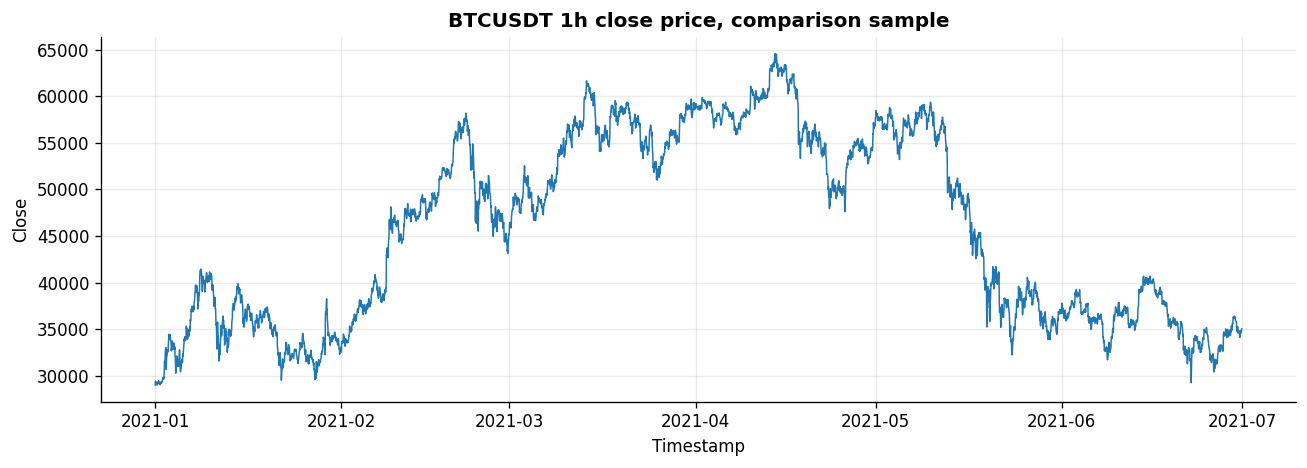

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_btc_baseline_log_return.png


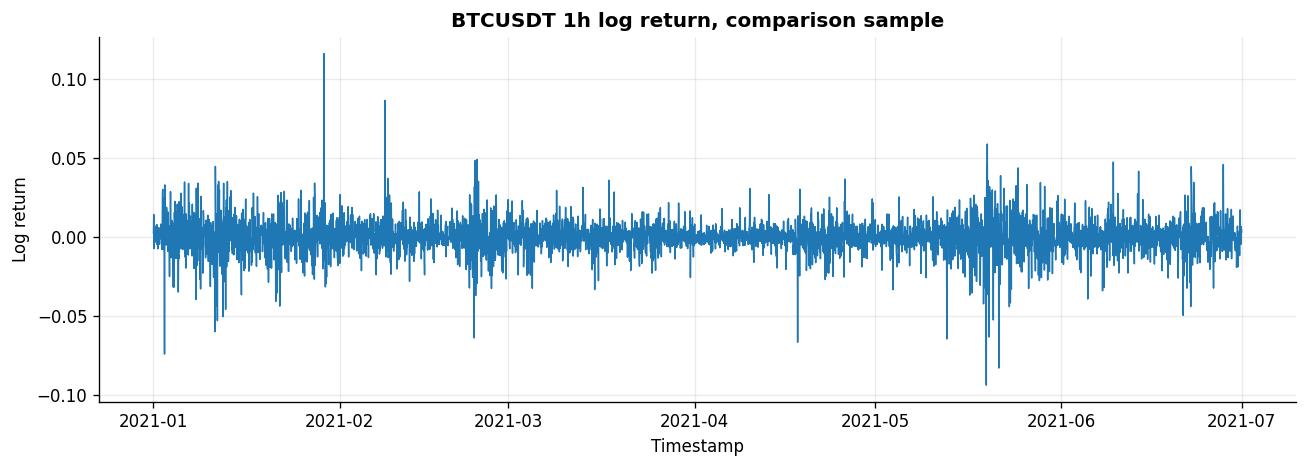

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_btc_baseline_volatility.png


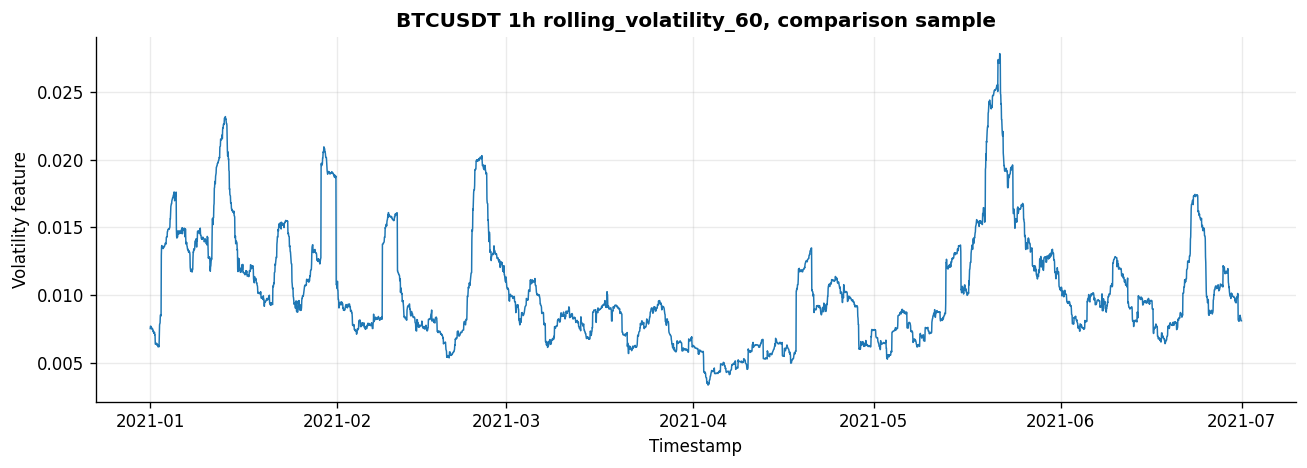

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_btc_baseline_multichannel.png


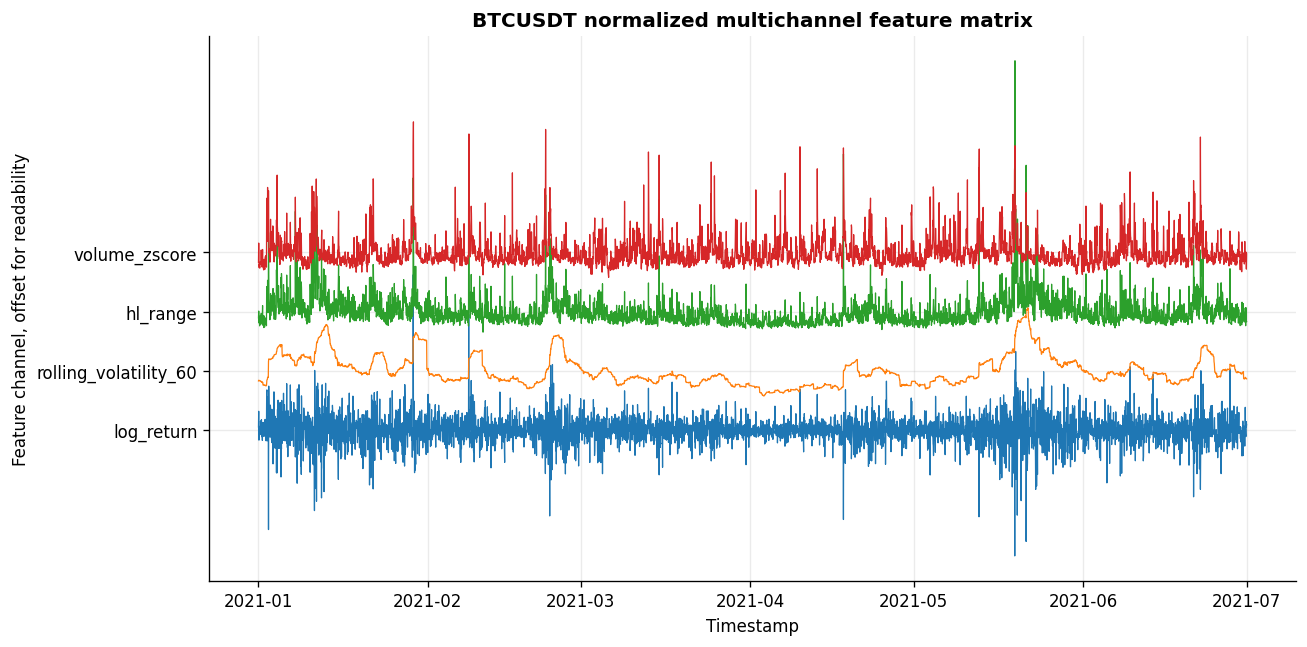

In [6]:
btc = prepared["BTCUSDT"]
btc_clean = btc["data"]
btc_features = btc["features"]
btc_z = btc["z_features"]
btc_timestamps = btc["timestamps"]
btc_univariate = btc["univariate"]
btc_multivariate = btc["multivariate"]
btc_volatility_feature = next((col for col in btc_features if "volatility" in col.lower()), None)

def plot_btc_column(column, title, ylabel, filename):
    if column is None or column not in btc_clean.columns:
        warnings.warn(f"Skipping plot because {column!r} is unavailable.")
        return None
    fig, ax = plt.subplots(figsize=(11, 4.0))
    ax.plot(btc_clean["timestamp"], btc_clean[column], linewidth=0.9)
    ax.set_title(title)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel(ylabel)
    path = save_plot(fig, REPORT_DIR / filename)
    plt.show()
    plt.close(fig)
    return path

plot_btc_column("close", "BTCUSDT 1h close price, comparison sample", "Close", "02_btc_baseline_close.png")
plot_btc_column("log_return", "BTCUSDT 1h log return, comparison sample", "Log return", "02_btc_baseline_log_return.png")
plot_btc_column(btc_volatility_feature, f"BTCUSDT 1h {btc_volatility_feature}, comparison sample", "Volatility feature", "02_btc_baseline_volatility.png")

fig, ax = plt.subplots(figsize=(11, 5.5))
offsets = np.arange(len(btc_features), dtype=float) * 4.0
for offset, feature in zip(offsets, btc_features):
    ax.plot(btc_timestamps, btc_z[feature] + offset, linewidth=0.75)
ax.set_yticks(offsets)
ax.set_yticklabels(btc_features)
ax.set_title("BTCUSDT normalized multichannel feature matrix")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Feature channel, offset for readability")
save_plot(fig, REPORT_DIR / "02_btc_baseline_multichannel.png")
plt.show()
plt.close(fig)


## 7. Matrix Profile univariate baseline

This is the fixed-length benchmark on BTCUSDT `log_return`. If `stumpy` is unavailable, the section skips cleanly and writes the reason into the notebook output.


Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_mp_matrix_profile.png


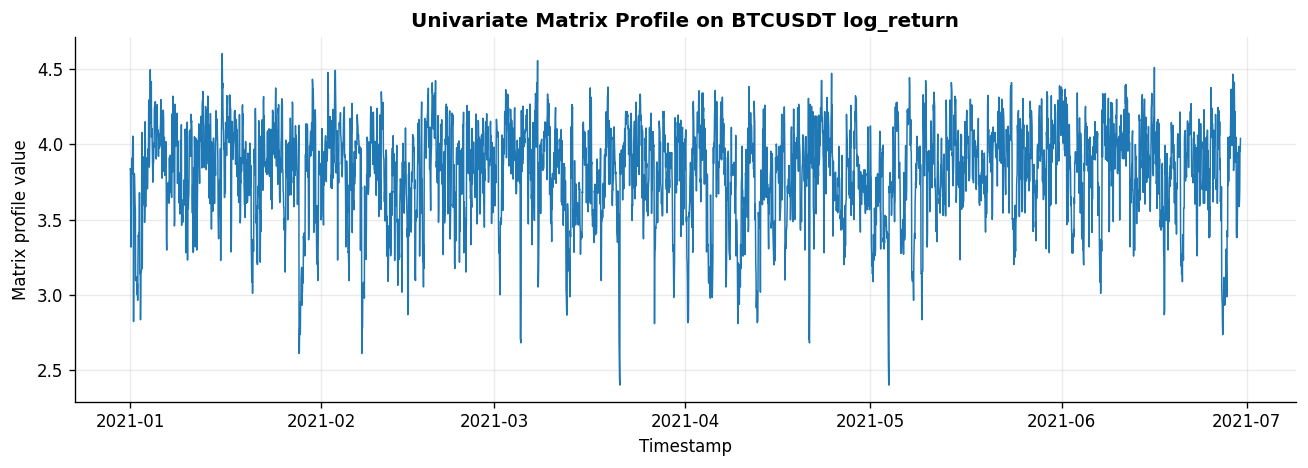

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_mp_top_motif_overlay.png


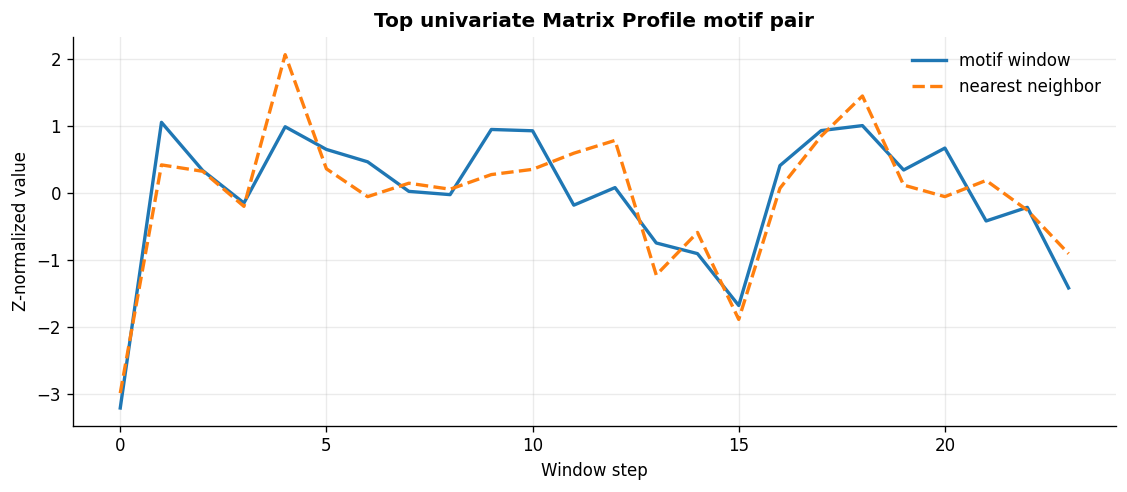

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_mp_top_motifs_on_series.png


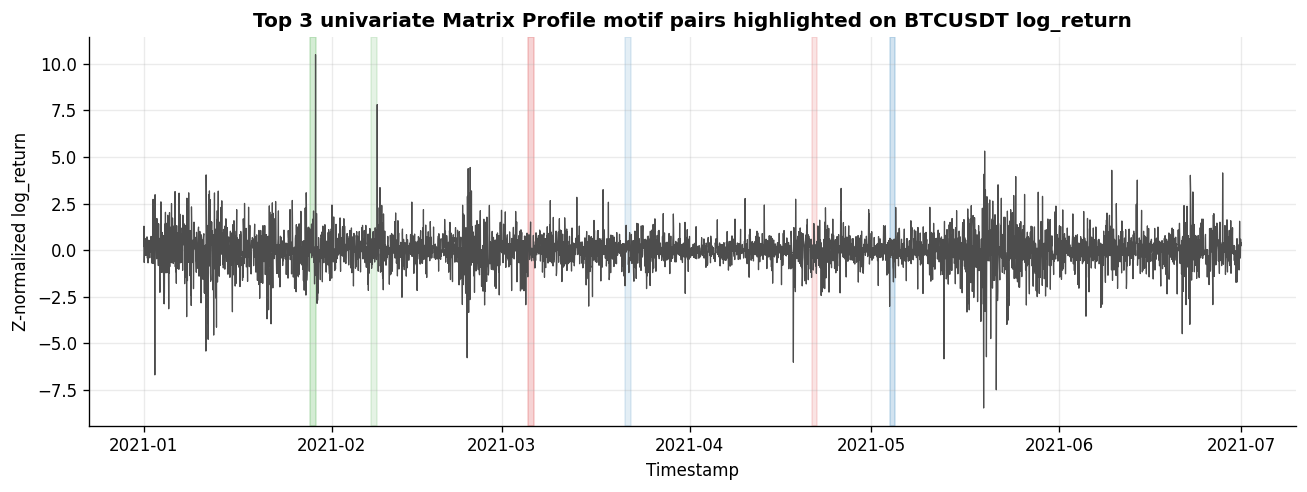

Univariate Matrix Profile runtime: 23.921 seconds


,rank,motif_start,motif_end,neighbor_start,neighbor_end,profile_value,window_size,method,asset,frequency,motif_index,neighbor_index,runtime_seconds
0,1,2021-05-04T00:00:00+00:00,2021-05-04T23:00:00+00:00,2021-03-21T09:00:00+00:00,2021-03-22T08:00:00+00:00,2.400611,24,Univariate Matrix Profile,BTCUSDT,1h,2945,1903,23.92088
1,2,2021-01-28T09:00:00+00:00,2021-01-29T08:00:00+00:00,2021-02-07T13:00:00+00:00,2021-02-08T12:00:00+00:00,2.610733,24,Univariate Matrix Profile,BTCUSDT,1h,657,901,23.92088
2,3,2021-03-05T08:00:00+00:00,2021-03-06T08:00:00+00:00,2021-04-21T03:00:00+00:00,2021-04-22T02:00:00+00:00,2.681119,24,Univariate Matrix Profile,BTCUSDT,1h,1519,2639,23.92088
3,4,2021-03-27T00:00:00+00:00,2021-03-27T23:00:00+00:00,2021-04-09T12:00:00+00:00,2021-04-10T11:00:00+00:00,2.808883,24,Univariate Matrix Profile,BTCUSDT,1h,2038,2362,23.92088
4,5,2021-04-01T10:00:00+00:00,2021-04-02T09:00:00+00:00,2021-04-12T16:00:00+00:00,2021-04-13T15:00:00+00:00,2.815471,24,Univariate Matrix Profile,BTCUSDT,1h,2168,2438,23.92088


In [7]:
mp_univariate_runtime = None
mp_univariate_profile = None
mp_univariate_indices = None
mp_univariate_table = pd.DataFrame()
mp_univariate_note = ""

if STUMPY_AVAILABLE and CONFIG["run_matrix_profile"]:
    t0 = time.perf_counter()
    mp_univariate = stumpy.stump(btc_univariate.astype(np.float64), m=CONFIG["mp_window"])
    mp_univariate_runtime = time.perf_counter() - t0
    mp_univariate_profile = mp_univariate[:, 0].astype(float)
    mp_univariate_indices = mp_univariate[:, 1].astype(int)

    mp_univariate_table = extract_top_mp_motifs(
        mp_univariate_profile,
        mp_univariate_indices,
        timestamps=btc_timestamps,
        window_size=CONFIG["mp_window"],
        top_k=CONFIG["top_k"],
        method="Univariate Matrix Profile",
        asset=CONFIG["asset"],
        frequency=CONFIG["frequency"],
    )
    mp_univariate_table["runtime_seconds"] = mp_univariate_runtime
    mp_univariate_table.to_csv(REPORT_DIR / "02_mp_univariate_motif_table.csv", index=False)

    fig, ax = plt.subplots(figsize=(11, 4.0))
    ax.plot(btc_timestamps.iloc[:len(mp_univariate_profile)], mp_univariate_profile, linewidth=0.9)
    ax.set_title("Univariate Matrix Profile on BTCUSDT log_return")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Matrix profile value")
    save_plot(fig, REPORT_DIR / "02_mp_matrix_profile.png")
    plt.show()
    plt.close(fig)

    if not mp_univariate_table.empty:
        top_row = mp_univariate_table.iloc[0]
        fig = plot_motif_pair_overlay(
            btc_univariate,
            top_row["motif_index"],
            top_row["neighbor_index"],
            CONFIG["mp_window"],
            title="Top univariate Matrix Profile motif pair",
        )
        save_plot(fig, REPORT_DIR / "02_mp_top_motif_overlay.png")
        plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(11, 4.2))
        ax.plot(btc_timestamps, btc_univariate, color="#4d4d4d", linewidth=0.75)
        highlight_colors = ["#1f77b4", "#2ca02c", "#d62728"]
        for row, color in zip(mp_univariate_table.head(3).itertuples(index=False), highlight_colors):
            ax.axvspan(pd.Timestamp(row.motif_start), pd.Timestamp(row.motif_end), color=color, alpha=0.20)
            ax.axvspan(pd.Timestamp(row.neighbor_start), pd.Timestamp(row.neighbor_end), color=color, alpha=0.12)
        ax.set_title("Top 3 univariate Matrix Profile motif pairs highlighted on BTCUSDT log_return")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Z-normalized log_return")
        save_plot(fig, REPORT_DIR / "02_mp_top_motifs_on_series.png")
        plt.show()
        plt.close(fig)

    print(f"Univariate Matrix Profile runtime: {mp_univariate_runtime:.3f} seconds")
else:
    mp_univariate_note = "stumpy is not available or Matrix Profile execution is disabled."
    print(mp_univariate_note)

mp_univariate_table


## 8. Matrix Profile multivariate baseline

Multivariate Matrix Profile gives the closest fixed-length baseline to LoCoMotif when both methods use the same engineered channels. The input orientation for `stumpy.mstump` is dimensions by time.


Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_mp_multivariate_profile.png


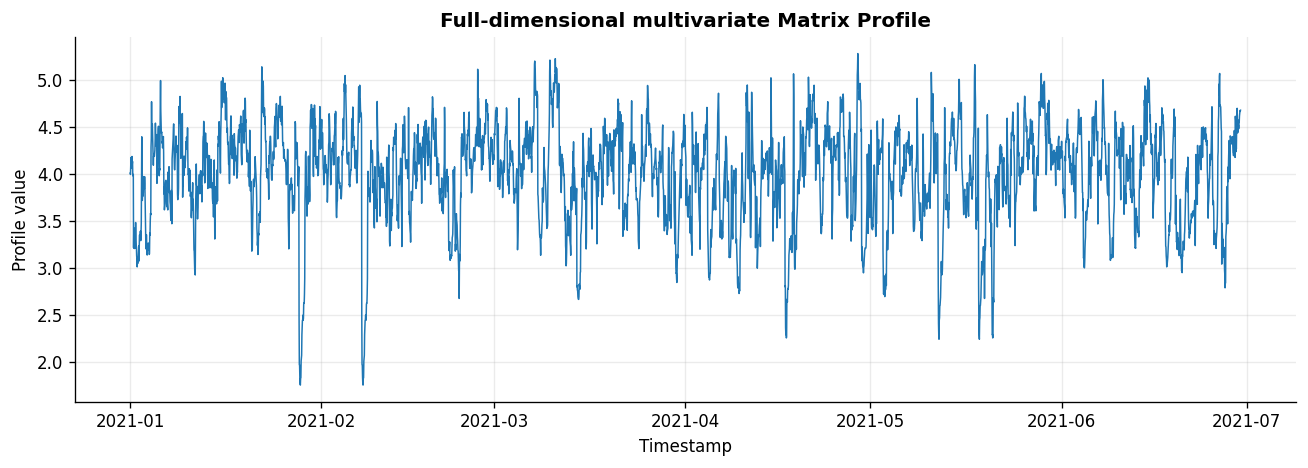

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\02_mp_multivariate_top_motif_overlay.png


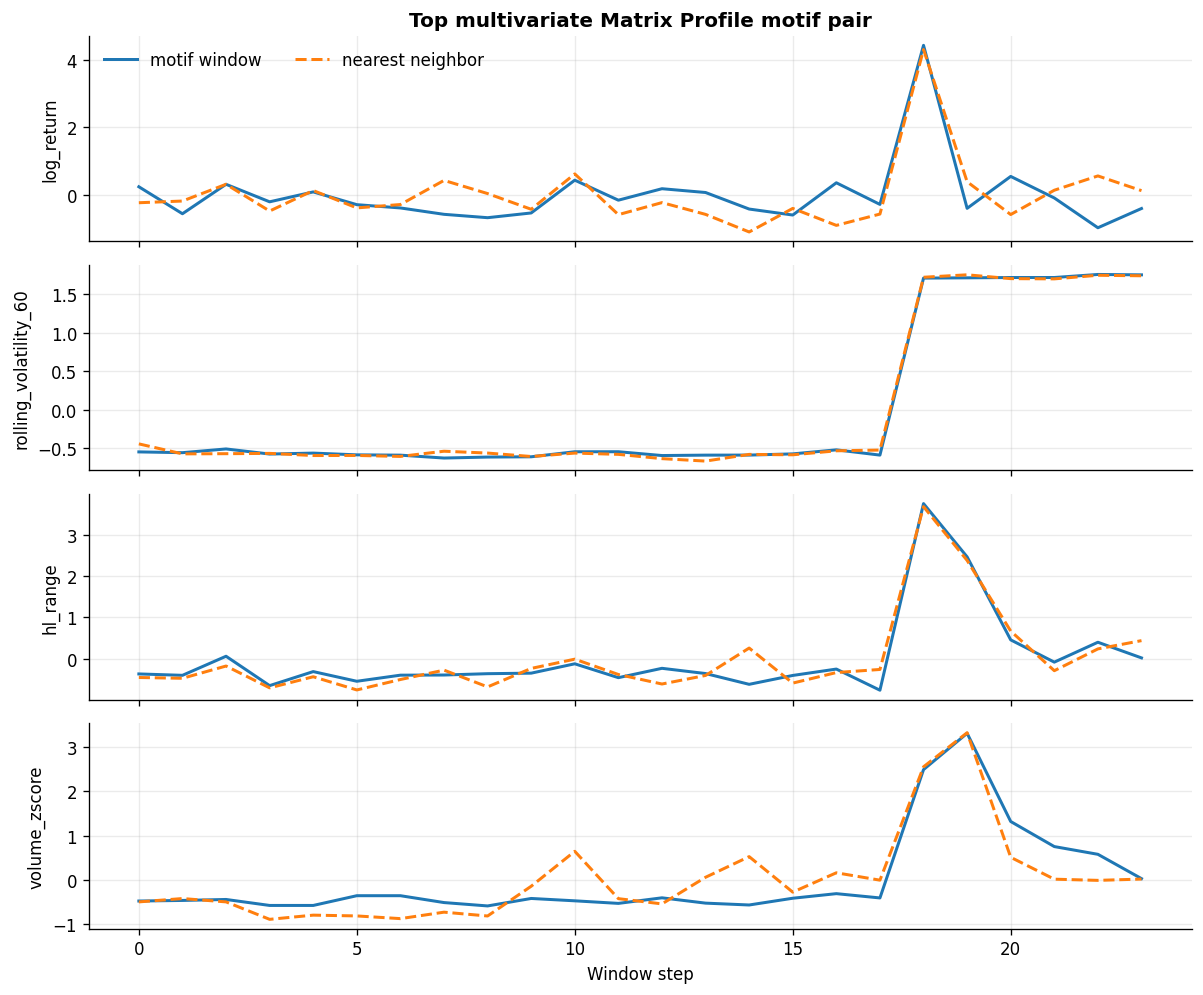

Multivariate Matrix Profile runtime: 4.370 seconds


,rank,motif_start,motif_end,neighbor_start,neighbor_end,profile_value,window_size,method,asset,frequency,motif_index,neighbor_index,runtime_seconds
0,1,2021-02-07T18:00:00+00:00,2021-02-08T17:00:00+00:00,2021-01-28T14:00:00+00:00,2021-01-29T13:00:00+00:00,1.753718,24,Multivariate Matrix Profile,BTCUSDT,1h,906,662,4.370007
1,2,2021-05-12T03:00:00+00:00,2021-05-13T02:00:00+00:00,2021-05-18T16:00:00+00:00,2021-05-19T15:00:00+00:00,2.241655,24,Multivariate Matrix Profile,BTCUSDT,1h,3140,3297,4.370007
2,3,2021-05-20T20:00:00+00:00,2021-05-21T19:00:00+00:00,2021-04-17T09:00:00+00:00,2021-04-18T08:00:00+00:00,2.255623,24,Multivariate Matrix Profile,BTCUSDT,1h,3349,2551,4.370007
3,4,2021-06-27T12:00:00+00:00,2021-06-28T11:00:00+00:00,2021-04-09T18:00:00+00:00,2021-04-10T17:00:00+00:00,2.788563,24,Multivariate Matrix Profile,BTCUSDT,1h,4253,2368,4.370007
4,5,2021-01-11T13:00:00+00:00,2021-01-12T12:00:00+00:00,2021-02-23T08:00:00+00:00,2021-02-24T07:00:00+00:00,2.925573,24,Multivariate Matrix Profile,BTCUSDT,1h,253,1279,4.370007


In [8]:
mp_multivariate_runtime = None
mp_multivariate_profile = None
mp_multivariate_indices = None
mp_multivariate_table = pd.DataFrame()
mp_multivariate_note = ""

if STUMPY_AVAILABLE and CONFIG["run_matrix_profile"]:
    try:
        if not hasattr(stumpy, "mstump"):
            raise AttributeError("This stumpy version does not expose mstump.")

        X_mstump = btc_multivariate.T.astype(np.float64)
        t0 = time.perf_counter()
        mps, indices = stumpy.mstump(X_mstump, m=CONFIG["mp_window"])
        mp_multivariate_runtime = time.perf_counter() - t0

        mp_multivariate_profile = np.asarray(mps[-1], dtype=float)
        mp_multivariate_indices = np.asarray(indices[-1], dtype=int)

        mp_multivariate_table = extract_top_mp_motifs(
            mp_multivariate_profile,
            mp_multivariate_indices,
            timestamps=btc_timestamps,
            window_size=CONFIG["mp_window"],
            top_k=CONFIG["top_k"],
            method="Multivariate Matrix Profile",
            asset=CONFIG["asset"],
            frequency=CONFIG["frequency"],
        )
        mp_multivariate_table["runtime_seconds"] = mp_multivariate_runtime
        mp_multivariate_table.to_csv(REPORT_DIR / "02_mp_multivariate_motif_table.csv", index=False)

        fig, ax = plt.subplots(figsize=(11, 4.0))
        ax.plot(btc_timestamps.iloc[:len(mp_multivariate_profile)], mp_multivariate_profile, linewidth=0.9)
        ax.set_title("Full-dimensional multivariate Matrix Profile")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Profile value")
        save_plot(fig, REPORT_DIR / "02_mp_multivariate_profile.png")
        plt.show()
        plt.close(fig)

        if not mp_multivariate_table.empty:
            top_row = mp_multivariate_table.iloc[0]
            fig = plot_motif_pair_overlay(
                btc_multivariate,
                top_row["motif_index"],
                top_row["neighbor_index"],
                CONFIG["mp_window"],
                feature_names=btc_features,
                title="Top multivariate Matrix Profile motif pair",
            )
            save_plot(fig, REPORT_DIR / "02_mp_multivariate_top_motif_overlay.png")
            plt.show()
            plt.close(fig)

        print(f"Multivariate Matrix Profile runtime: {mp_multivariate_runtime:.3f} seconds")
    except Exception as exc:
        mp_multivariate_note = f"Multivariate Matrix Profile skipped due to: {type(exc).__name__}: {exc}"
        warnings.warn(mp_multivariate_note)
        pd.DataFrame([{"issue": mp_multivariate_note}]).to_csv(
            REPORT_DIR / "02_mp_multivariate_motif_table.csv", index=False
        )
else:
    mp_multivariate_note = "stumpy is not available or Matrix Profile execution is disabled."
    print(mp_multivariate_note)

mp_multivariate_table


## 9. LoCoMotif initial run or prepared interface

LoCoMotif discovers motif sets rather than only nearest-neighbor pairs, so the output table must support multiple occurrences per motif set. The adapter below runs the documented `apply_locomotif` API when available. To keep this notebook as an initial study rather than a full experiment, the real LoCoMotif call is capped to the first 240 hourly observations.


In [9]:
def run_locomotif_adapter(X, timestamps, config):
    t0 = time.perf_counter()
    if LOCOMOTIF_MODULE is None:
        return None, time.perf_counter() - t0, (
            "LoCoMotif package is not installed. Data and feature matrix are prepared; "
            "connect the adapter to the installed LoCoMotif API."
        )

    if not hasattr(LOCOMOTIF_MODULE, "apply_locomotif"):
        public_callables = sorted(
            name for name, obj in inspect.getmembers(LOCOMOTIF_MODULE) if callable(obj) and not name.startswith("_")
        )
        return None, time.perf_counter() - t0, (
            f"Module {LOCOMOTIF_MODULE_NAME!r} imported, but no safe known callable was detected. "
            f"Public callables include: {public_callables[:20]}"
        )

    max_points = int(config.get("locomotif_max_points", 240))
    X_run = np.asarray(X[:max_points], dtype=np.float32)
    timestamps_run = pd.Series(timestamps).reset_index(drop=True).iloc[:max_points].reset_index(drop=True)

    motif_sets = LOCOMOTIF_MODULE.apply_locomotif(
        X_run,
        l_min=int(config.get("locomotif_l_min", 12)),
        l_max=int(config.get("locomotif_l_max", 30)),
        rho=float(config.get("locomotif_rho", 0.7)),
        nb=int(config.get("locomotif_nb", 3)),
        overlap=0.0,
        warping=True,
    )
    runtime = time.perf_counter() - t0

    rows = []
    for motif_set_rank, (representative, motif_set) in enumerate(motif_sets, start=1):
        for occurrence_id, occurrence in enumerate(motif_set, start=1):
            start_index = int(occurrence[0])
            end_exclusive = int(occurrence[1])
            end_index = max(start_index, end_exclusive - 1)
            rows.append({
                "rank": motif_set_rank,
                "motif_set_id": motif_set_rank,
                "occurrence_id": occurrence_id,
                "start": pd.Timestamp(timestamps_run.iloc[start_index]).isoformat(),
                "end": pd.Timestamp(timestamps_run.iloc[min(end_index, len(timestamps_run) - 1)]).isoformat(),
                "length": int(end_exclusive - start_index),
                "score": np.nan,
                "method": "LoCoMotif",
                "asset": config["asset"],
                "frequency": config["frequency"],
                "representative_start_index": int(representative[0]),
                "representative_end_index": int(representative[1]),
                "occurrence_start_index": start_index,
                "occurrence_end_exclusive": end_exclusive,
                "runtime_seconds": runtime,
                "notes": f"Real dtai-locomotif run on first {len(X_run)} observations.",
            })

    return pd.DataFrame(rows), runtime, f"Executed real LoCoMotif via {LOCOMOTIF_MODULE_NAME}.apply_locomotif."


locomotif_result = None
locomotif_runtime = None
locomotif_note = "LoCoMotif execution disabled by config."

if CONFIG["run_locomotif"]:
    locomotif_result, locomotif_runtime, locomotif_note = run_locomotif_adapter(
        btc_multivariate,
        btc_timestamps,
        CONFIG,
    )

if locomotif_result is None:
    locomotif_output = pd.DataFrame([{
        "rank": np.nan,
        "motif_set_id": np.nan,
        "occurrence_id": np.nan,
        "start": pd.Timestamp(btc_timestamps.iloc[0]).isoformat(),
        "end": pd.Timestamp(btc_timestamps.iloc[-1]).isoformat(),
        "length": int(len(btc_timestamps)),
        "score": np.nan,
        "method": "LoCoMotif",
        "asset": CONFIG["asset"],
        "frequency": CONFIG["frequency"],
        "notes": locomotif_note,
        "expected_input_shape": str(btc_multivariate.shape),
        "expected_input_orientation": "time x channels",
    }])
else:
    locomotif_output = pd.DataFrame(locomotif_result)

locomotif_output.to_csv(REPORT_DIR / "02_locomotif_initial_results.csv", index=False)
print(locomotif_note)
locomotif_output


Executed real LoCoMotif via locomotif.locomotif.apply_locomotif.


,rank,motif_set_id,occurrence_id,start,end,length,score,method,asset,frequency,representative_start_index,representative_end_index,occurrence_start_index,occurrence_end_exclusive,runtime_seconds,notes
0,1,1,1,2021-01-05T10:00:00+00:00,2021-01-05T22:00:00+00:00,13,NaN,LoCoMotif,BTCUSDT,1h,106,119,106,119,2.297606,Real dtai-locomotif run on first 240 observati...
1,1,1,2,2021-01-07T22:00:00+00:00,2021-01-08T11:00:00+00:00,14,NaN,LoCoMotif,BTCUSDT,1h,106,119,166,180,2.297606,Real dtai-locomotif run on first 240 observati...
2,1,1,3,2021-01-04T04:00:00+00:00,2021-01-04T19:00:00+00:00,16,NaN,LoCoMotif,BTCUSDT,1h,106,119,76,92,2.297606,Real dtai-locomotif run on first 240 observati...
3,1,1,4,2021-01-06T13:00:00+00:00,2021-01-07T03:00:00+00:00,15,NaN,LoCoMotif,BTCUSDT,1h,106,119,133,148,2.297606,Real dtai-locomotif run on first 240 observati...
4,1,1,5,2021-01-02T23:00:00+00:00,2021-01-03T11:00:00+00:00,13,NaN,LoCoMotif,BTCUSDT,1h,106,119,47,60,2.297606,Real dtai-locomotif run on first 240 observati...
5,1,1,6,2021-01-08T14:00:00+00:00,2021-01-09T01:00:00+00:00,12,NaN,LoCoMotif,BTCUSDT,1h,106,119,182,194,2.297606,Real dtai-locomotif run on first 240 observati...
6,1,1,7,2021-01-07T07:00:00+00:00,2021-01-07T21:00:00+00:00,15,NaN,LoCoMotif,BTCUSDT,1h,106,119,151,166,2.297606,Real dtai-locomotif run on first 240 observati...
7,1,1,8,2021-01-10T03:00:00+00:00,2021-01-10T15:00:00+00:00,13,NaN,LoCoMotif,BTCUSDT,1h,106,119,219,232,2.297606,Real dtai-locomotif run on first 240 observati...
8,1,1,9,2021-01-04T20:00:00+00:00,2021-01-05T08:00:00+00:00,13,NaN,LoCoMotif,BTCUSDT,1h,106,119,92,105,2.297606,Real dtai-locomotif run on first 240 observati...
9,1,1,10,2021-01-03T14:00:00+00:00,2021-01-04T02:00:00+00:00,13,NaN,LoCoMotif,BTCUSDT,1h,106,119,62,75,2.297606,Real dtai-locomotif run on first 240 observati...


## 10. Optional simplified time-warped motif proxy for sanity only

**Educational DTW proxy, not LoCoMotif, not used as final result.**

If LoCoMotif is unavailable or the real adapter cannot run, the next cell computes a small DTW proxy on candidate BTC log-return windows of lengths 18, 24, and 30. This only illustrates why time-warp-tolerant comparison may be useful. When a real LoCoMotif result is available, the proxy is skipped.


In [10]:
dtw_proxy_used = locomotif_result is None
dtw_proxy_runtime = None
dtw_proxy_results = pd.DataFrame()

if dtw_proxy_used:
    t0 = time.perf_counter()
    if not mp_univariate_table.empty:
        anchor_start = int(mp_univariate_table.iloc[0]["motif_index"])
    else:
        anchor_start = 0

    anchor_length = CONFIG["mp_window"]
    anchor = btc_univariate[anchor_start:anchor_start + anchor_length]
    candidate_rows = []
    candidate_lengths = [18, 24, 30]
    step = max(6, CONFIG["mp_window"] // 2)

    for candidate_length in candidate_lengths:
        for start_index in range(0, len(btc_univariate) - candidate_length, step):
            if abs(start_index - anchor_start) < CONFIG["mp_window"]:
                continue
            candidate = btc_univariate[start_index:start_index + candidate_length]
            distance = dtw_distance(z_normalize_array(anchor), z_normalize_array(candidate))
            candidate_rows.append({
                "anchor_start_index": anchor_start,
                "candidate_start_index": start_index,
                "candidate_length": candidate_length,
                "dtw_distance": distance,
                "candidate_start": pd.Timestamp(btc_timestamps.iloc[start_index]).isoformat(),
                "candidate_end": pd.Timestamp(btc_timestamps.iloc[start_index + candidate_length - 1]).isoformat(),
            })

    dtw_proxy_results = (
        pd.DataFrame(candidate_rows)
          .sort_values("dtw_distance")
          .head(10)
          .reset_index(drop=True)
    )
    dtw_proxy_runtime = time.perf_counter() - t0
    dtw_proxy_results.to_csv(REPORT_DIR / "02_educational_dtw_proxy_results.csv", index=False)

    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    ax.plot(np.linspace(0, 1, len(anchor)), z_normalize_array(anchor), linewidth=2.2, label="MP anchor motif")
    for rank, row in dtw_proxy_results.head(3).iterrows():
        candidate = btc_univariate[
            int(row["candidate_start_index"]):int(row["candidate_start_index"]) + int(row["candidate_length"])
        ]
        ax.plot(
            np.linspace(0, 1, len(candidate)),
            z_normalize_array(candidate),
            linewidth=1.6,
            linestyle="--",
            label=f"DTW proxy candidate {rank + 1}, length={int(row['candidate_length'])}",
        )
    ax.set_title("Educational DTW proxy overlay, not LoCoMotif")
    ax.set_xlabel("Normalized within-window time")
    ax.set_ylabel("Z-normalized log_return")
    ax.legend(frameon=False)
    save_plot(fig, REPORT_DIR / "02_dtw_proxy_overlay.png")
    plt.show()
    plt.close(fig)

    print(f"Educational DTW proxy runtime: {dtw_proxy_runtime:.3f} seconds")
else:
    print("Real LoCoMotif output is available. DTW proxy skipped.")

dtw_proxy_results


Real LoCoMotif output is available. DTW proxy skipped.


""


## 11. Initial comparison table

This table records what was actually available in this controlled run. Placeholder outputs are marked clearly so they are not confused with real LoCoMotif results.


In [11]:
comparison_rows = [
    {
        "method": "Univariate Matrix Profile",
        "input_type": "univariate",
        "features": ", ".join(CONFIG["features_univariate"]),
        "fixed_or_variable_length": "fixed",
        "time_warping": "no",
        "runtime_seconds": mp_univariate_runtime,
        "number_of_motifs_found": int(len(mp_univariate_table)),
        "output_available": bool(not mp_univariate_table.empty),
        "notes": mp_univariate_note or "Executed with stumpy.stump.",
    },
    {
        "method": "Multivariate Matrix Profile",
        "input_type": "multivariate",
        "features": ", ".join(btc_features),
        "fixed_or_variable_length": "fixed",
        "time_warping": "no",
        "runtime_seconds": mp_multivariate_runtime,
        "number_of_motifs_found": int(len(mp_multivariate_table)),
        "output_available": bool(not mp_multivariate_table.empty),
        "notes": mp_multivariate_note or "Executed with stumpy.mstump.",
    },
    {
        "method": "LoCoMotif",
        "input_type": "multivariate",
        "features": ", ".join(btc_features),
        "fixed_or_variable_length": "variable",
        "time_warping": "yes",
        "runtime_seconds": locomotif_runtime,
        "number_of_motifs_found": 0 if locomotif_result is None else int(locomotif_output["motif_set_id"].nunique()),
        "output_available": bool(locomotif_result is not None),
        "notes": locomotif_note,
    },
]

if dtw_proxy_used:
    comparison_rows.append({
        "method": "Educational DTW proxy",
        "input_type": "univariate",
        "features": "log_return",
        "fixed_or_variable_length": "variable candidate lengths",
        "time_warping": "yes, DTW",
        "runtime_seconds": dtw_proxy_runtime,
        "number_of_motifs_found": int(len(dtw_proxy_results)),
        "output_available": bool(not dtw_proxy_results.empty),
        "notes": "Educational proxy only; not LoCoMotif and not part of the final benchmark.",
    })

initial_method_comparison = pd.DataFrame(comparison_rows)
initial_method_comparison.to_csv(REPORT_DIR / "02_initial_method_comparison.csv", index=False)
initial_method_comparison


,method,input_type,features,fixed_or_variable_length,time_warping,runtime_seconds,number_of_motifs_found,output_available,notes
0,Univariate Matrix Profile,univariate,log_return,fixed,no,23.920880,5,True,Executed with stumpy.stump.
1,Multivariate Matrix Profile,multivariate,"log_return, rolling_volatility_60, hl_range, v...",fixed,no,4.370007,5,True,Executed with stumpy.mstump.
2,LoCoMotif,multivariate,"log_return, rolling_volatility_60, hl_range, v...",variable,yes,2.297606,3,True,Executed real LoCoMotif via locomotif.locomoti...


## 12. Thesis comparison logic

Matrix Profile and LoCoMotif should not be compared only by visual motif quality. The benchmark should compare runtime, motif stability, motif recurrence, regime purity, cross-regime persistence, interpretability, and robustness across frequency and feature representation.


In [12]:
evaluation_dimensions = pd.DataFrame([
    {
        "Evaluation dimension": "runtime",
        "Definition": "Wall-clock time for a controlled sample and feature set",
        "Matrix Profile output used": "runtime_seconds from stump/mstump",
        "LoCoMotif output used": "runtime_seconds from adapter",
        "Planned metric": "seconds; scaling by sample length",
    },
    {
        "Evaluation dimension": "motif length behavior",
        "Definition": "Whether discovered motifs have fixed or variable duration",
        "Matrix Profile output used": "window_size",
        "LoCoMotif output used": "occurrence start/end length",
        "Planned metric": "length distribution and coefficient of variation",
    },
    {
        "Evaluation dimension": "stability score",
        "Definition": "Persistence of similar motifs across nearby parameter settings",
        "Matrix Profile output used": "top-k motif pair indices",
        "LoCoMotif output used": "motif set occurrence intervals",
        "Planned metric": "Jaccard overlap of motif intervals",
    },
    {
        "Evaluation dimension": "regime purity",
        "Definition": "Share of motif occurrences inside the same regime",
        "Matrix Profile output used": "motif pair timestamps",
        "LoCoMotif output used": "motif set occurrence timestamps",
        "Planned metric": "majority-regime share",
    },
    {
        "Evaluation dimension": "recurrence count",
        "Definition": "How often the motif appears in the sample",
        "Matrix Profile output used": "non-overlapping top-k pairs",
        "LoCoMotif output used": "occurrence count per motif set",
        "Planned metric": "count per motif or motif set",
    },
    {
        "Evaluation dimension": "cross-asset overlap",
        "Definition": "Whether BTC and ETH motifs align in time or shape",
        "Matrix Profile output used": "BTC/ETH motif intervals",
        "LoCoMotif output used": "BTC/ETH motif set intervals",
        "Planned metric": "temporal overlap and nearest-event lag",
    },
    {
        "Evaluation dimension": "external event overlap",
        "Definition": "Whether motifs cluster around known market events",
        "Matrix Profile output used": "motif timestamps",
        "LoCoMotif output used": "occurrence timestamps",
        "Planned metric": "event-window hit rate",
    },
])
evaluation_dimensions.to_csv(REPORT_DIR / "02_evaluation_dimensions.csv", index=False)
evaluation_dimensions


,Evaluation dimension,Definition,Matrix Profile output used,LoCoMotif output used,Planned metric
0,runtime,Wall-clock time for a controlled sample and fe...,runtime_seconds from stump/mstump,runtime_seconds from adapter,seconds; scaling by sample length
1,motif length behavior,Whether discovered motifs have fixed or variab...,window_size,occurrence start/end length,length distribution and coefficient of variation
2,stability score,Persistence of similar motifs across nearby pa...,top-k motif pair indices,motif set occurrence intervals,Jaccard overlap of motif intervals
3,regime purity,Share of motif occurrences inside the same regime,motif pair timestamps,motif set occurrence timestamps,majority-regime share
4,recurrence count,How often the motif appears in the sample,non-overlapping top-k pairs,occurrence count per motif set,count per motif or motif set
5,cross-asset overlap,Whether BTC and ETH motifs align in time or shape,BTC/ETH motif intervals,BTC/ETH motif set intervals,temporal overlap and nearest-event lag
6,external event overlap,Whether motifs cluster around known market events,motif timestamps,occurrence timestamps,event-window hit rate


## 13. Preparing for regime-conditioned comparison

The upcoming flow is:

1. Generate volatility-quantile labels on BTC/ETH 1-hour data.
2. Generate HMM labels on BTC/ETH 1-hour feature matrices.
3. Run Matrix Profile and LoCoMotif on the full sample, volatility regimes, and HMM states.
4. Compare stability and interpretability.


In [13]:
planned_rows = []
assets = ["BTCUSDT", "ETHUSDT"]
frequencies = [
    ("1h", "default_core_multivariate"),
    ("15m", "robustness_core_multivariate"),
]
regimes = [
    ("full_sample", "full_sample"),
    ("volatility_quantile", "volatility_quantile_low"),
    ("volatility_quantile", "volatility_quantile_medium"),
    ("volatility_quantile", "volatility_quantile_high"),
    ("hmm", "hmm_state_0"),
    ("hmm", "hmm_state_1"),
    ("hmm", "hmm_state_2"),
]
methods = ["Matrix Profile", "LoCoMotif"]

for asset in assets:
    for frequency, feature_set in frequencies:
        for regime_method, regime_label in regimes:
            for method in methods:
                planned_rows.append({
                    "asset": asset,
                    "frequency": frequency,
                    "feature_set": feature_set,
                    "regime_method": regime_method,
                    "regime_label": regime_label,
                    "method": method,
                    "status": "planned",
                })

planned_experiment_grid = pd.DataFrame(planned_rows)
planned_experiment_grid.to_csv(
    REPORT_DIR / "02_planned_regime_conditioned_experiment_grid.csv",
    index=False,
)
planned_experiment_grid.head(12)


,asset,frequency,feature_set,regime_method,regime_label,method,status
0,BTCUSDT,1h,default_core_multivariate,full_sample,full_sample,Matrix Profile,planned
1,BTCUSDT,1h,default_core_multivariate,full_sample,full_sample,LoCoMotif,planned
2,BTCUSDT,1h,default_core_multivariate,volatility_quantile,volatility_quantile_low,Matrix Profile,planned
3,BTCUSDT,1h,default_core_multivariate,volatility_quantile,volatility_quantile_low,LoCoMotif,planned
4,BTCUSDT,1h,default_core_multivariate,volatility_quantile,volatility_quantile_medium,Matrix Profile,planned
5,BTCUSDT,1h,default_core_multivariate,volatility_quantile,volatility_quantile_medium,LoCoMotif,planned
6,BTCUSDT,1h,default_core_multivariate,volatility_quantile,volatility_quantile_high,Matrix Profile,planned
7,BTCUSDT,1h,default_core_multivariate,volatility_quantile,volatility_quantile_high,LoCoMotif,planned
8,BTCUSDT,1h,default_core_multivariate,hmm,hmm_state_0,Matrix Profile,planned
9,BTCUSDT,1h,default_core_multivariate,hmm,hmm_state_0,LoCoMotif,planned


## 14. Final summary and next actions

Next actions:

- Connect the real LoCoMotif package/API if it is not installed in the active environment.
- Finalize the volatility-quantile regime notebook.
- Finalize the HMM regime notebook.
- Run controlled Matrix Profile vs LoCoMotif comparisons inside regimes.
- Produce benchmark tables for runtime, stability, regime purity, recurrence, and interpretability.


In [14]:
summary_02 = {
    "notebook": "02_matrix_profile_vs_locomotif_initial_comparison",
    "asset": CONFIG["asset"],
    "frequency": CONFIG["frequency"],
    "sample_start": pd.Timestamp(btc_timestamps.min()).isoformat(),
    "sample_end": pd.Timestamp(btc_timestamps.max()).isoformat(),
    "rows": int(len(btc_timestamps)),
    "features_univariate": CONFIG["features_univariate"],
    "features_multivariate": btc_features,
    "mp_window": CONFIG["mp_window"],
    "stumpy_available": STUMPY_AVAILABLE,
    "locomotif_available": LOCOMOTIF_AVAILABLE,
    "matrix_profile_univariate_runtime_seconds": mp_univariate_runtime,
    "matrix_profile_multivariate_runtime_seconds": mp_multivariate_runtime,
    "locomotif_runtime_seconds": locomotif_runtime,
    "locomotif_note": locomotif_note,
    "dtw_proxy_used": dtw_proxy_used,
    "outputs": {
        "loaded_data_summary": "02_loaded_data_summary.csv",
        "univariate_mp_table": "02_mp_univariate_motif_table.csv",
        "multivariate_mp_table": "02_mp_multivariate_motif_table.csv",
        "locomotif_results": "02_locomotif_initial_results.csv",
        "initial_method_comparison": "02_initial_method_comparison.csv",
        "planned_grid": "02_planned_regime_conditioned_experiment_grid.csv",
    },
}

with open(REPORT_DIR / "02_initial_comparison_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_02, f, indent=2)

summary_02


{'notebook': '02_matrix_profile_vs_locomotif_initial_comparison',
 'asset': 'BTCUSDT',
 'frequency': '1h',
 'sample_start': '2021-01-01T00:00:00+00:00',
 'sample_end': '2021-06-30T23:00:00+00:00',
 'rows': 4337,
 'features_univariate': ['log_return'],
 'features_multivariate': ['log_return',
  'rolling_volatility_60',
  'hl_range',
  'volume_zscore'],
 'mp_window': 24,
 'stumpy_available': True,
 'locomotif_available': True,
 'matrix_profile_univariate_runtime_seconds': 23.920880099998612,
 'matrix_profile_multivariate_runtime_seconds': 4.370006699995429,
 'locomotif_runtime_seconds': 2.29760620000161,
 'locomotif_note': 'Executed real LoCoMotif via locomotif.locomotif.apply_locomotif.',
 'dtw_proxy_used': False,
 'outputs': {'loaded_data_summary': '02_loaded_data_summary.csv',
  'univariate_mp_table': '02_mp_univariate_motif_table.csv',
  'multivariate_mp_table': '02_mp_multivariate_motif_table.csv',
  'locomotif_results': '02_locomotif_initial_results.csv',
  'initial_method_comparis